In [45]:
! pip install seaborn matplotlib scikit-learn

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [47]:
## creating datapoint 
from sklearn.datasets import make_classification 

In [48]:
X,y = make_classification(n_samples = 1000 , n_features = 2,n_classes= 2 ,n_clusters_per_class = 1 ,n_redundant = 0)

In [49]:
X

array([[ 0.77555656,  1.10269574],
       [-1.7545788 , -2.48663863],
       [-0.60708383,  0.49399981],
       ...,
       [ 0.683347  ,  0.92746633],
       [ 1.29017397,  1.20252128],
       [ 1.62564863,  1.0502465 ]], shape=(1000, 2))

In [50]:
y

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,

In [51]:
pd.DataFrame(X)[0]

0      0.775557
1     -1.754579
2     -0.607084
3     -0.478755
4     -1.238461
         ...   
995    2.277747
996    1.195047
997    0.683347
998    1.290174
999    1.625649
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

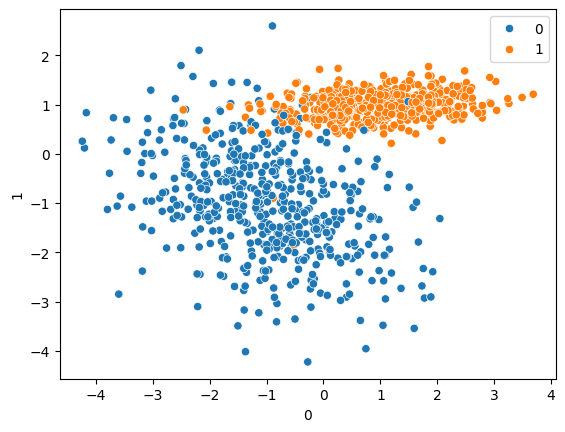

In [52]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [54]:
from sklearn.svm import SVC

In [55]:
svc = SVC(kernel = 'linear')

In [56]:
svc.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [57]:
y_pred = svc.predict(X_test)

In [58]:
from sklearn.metrics import classification_report,confusion_matrix

In [59]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       117
           1       0.97      0.99      0.98       133

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250

[[113   4]
 [  1 132]]


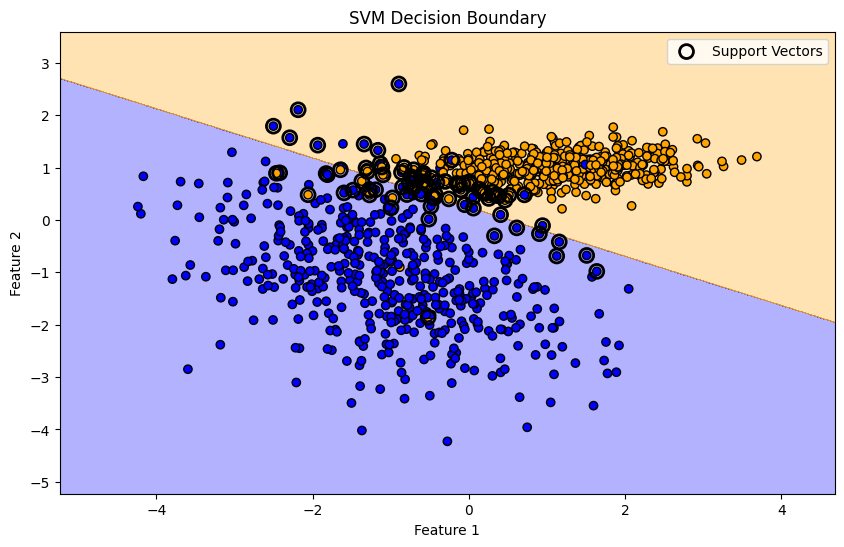

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# Predict for every point in meshgrid
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])

# Reshape output
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10,6))

plt.contourf(
    xx, yy, Z,
    alpha=0.3,
    cmap=ListedColormap(('blue', 'orange'))
)

# Plot actual datapoints
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap=ListedColormap(('blue', 'orange')),
    edgecolor='k'
)

# Highlight support vectors
plt.scatter(
    svc.support_vectors_[:,0],
    svc.support_vectors_[:,1],
    s=100,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")
plt.legend()

plt.show()